# Phase1 Direct 결과 분석

LiveCodeBench v6의 **stdin subset**에서 수행한 Direct Code Generation 결과를 분석한다.

기본 입력 파일: `outputs/direct_stdin/results.jsonl`

주요 분석 항목:
- 전체 Pass Rate 및 평가 상태 분포
- 난이도별 성능
- 테스트 통과 비율
- 생성 토큰 및 생성 시간
- 문제별 실패 사례와 첫 실패 테스트


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)


## 1. 결과 파일 로드


In [2]:
RESULT_PATH = Path('../direct_stdin/results.jsonl')

if not RESULT_PATH.exists():
    raise FileNotFoundError(
        f'Result file not found: {RESULT_PATH.resolve()}'
    )

records = []
with RESULT_PATH.open('r', encoding='utf-8') as file:
    for line_number, line in enumerate(file, start=1):
        if not line.strip():
            continue
        try:
            records.append(json.loads(line))
        except json.JSONDecodeError as error:
            raise ValueError(f'Invalid JSON at line {line_number}') from error

df = pd.DataFrame(records)
print(f'Loaded records: {len(df)}')
print(f'Columns: {len(df.columns)}')
display(df.head())


Loaded records: 10
Columns: 24


,problem_id,dataset,strategy,model_name,seed,title,platform,contest_id,contest_date,difficulty,problem,formatted_prompt,raw_output,extracted_code,prompt_tokens,completion_tokens,generation_time,passed,status,passed_tests,total_tests,execution_time,error_message,test_results
0,1873_A,livecodebench_v6,direct,Qwen/Qwen2.5-Coder-3B-Instruct,42,A. Short Sort,codeforces,1873,2023-08-21T00:00:00,easy,"There are three cards with letters $\texttt{a}$, $\texttt{b}$, $\texttt{c}$ placed in a row in some order. You can d...",Solve the following competitive programming problem in Python.\n\nRequirements:\n- Return only the final Python code...,```python\ndef can_sort(cards):\n # Check if the cards are already sorted\n if cards == 'abc':\n return...,def can_sort(cards):\n # Check if the cards are already sorted\n if cards == 'abc':\n return 'YES'\n ...,496,138,1.459637,False,WRONG_ANSWER,3,5,0.025685,"Test 0: expected='YES\nYES\nYES\nNO\nNO\nYES\n', actual='YES\nNO\nNO\nNO\nNO\nNO\n'","[{'test_index': 0, 'passed': False, 'status': 'WRONG_ANSWER', 'input_text': '6 abc acb bac bca cab cba ', 'expected_..."
1,1873_B,livecodebench_v6,direct,Qwen/Qwen2.5-Coder-3B-Instruct,42,B. Good Kid,codeforces,1873,2023-08-21T00:00:00,easy,Slavic is preparing a present for a friend's birthday. He has an array $a$ of $n$ digits and the present will be the...,Solve the following competitive programming problem in Python.\n\nRequirements:\n- Return only the final Python code...,"```python\ndef max_product_after_adding_one(n, digits):\n # Convert the list of digits to a string to easily mani...","def max_product_after_adding_one(n, digits):\n # Convert the list of digits to a string to easily manipulate indi...",391,255,2.316546,False,WRONG_ANSWER,12,13,0.279661,"Test 0: expected='16\n2\n432\n430467210\n', actual='16\n2\n432\n0\n'","[{'test_index': 0, 'passed': False, 'status': 'WRONG_ANSWER', 'input_text': '4 4 2 2 1 2 3 0 1 2 5 4 3 2 3 4 9 9 9 9..."
2,1873_D,livecodebench_v6,direct,Qwen/Qwen2.5-Coder-3B-Instruct,42,D. 1D Eraser,codeforces,1873,2023-08-21T00:00:00,easy,You are given a strip of paper $s$ that is $n$ cells long. Each cell is either black or white. In an operation you c...,Solve the following competitive programming problem in Python.\n\nRequirements:\n- Return only the final Python code...,"To solve the problem of removing all black cells from a strip of paper using the minimum number of operations, we ca...","def min_operations(n, k, s):\n dp = [float('inf')] * (n + 1)\n dp[0] = 0\n \n for i in range(1, n + 1):\...",607,626,5.689609,False,WRONG_ANSWER,0,13,6.448865,"Test 0: expected='2\n1\n2\n1\n4\n3\n4\n0\n', actual='1\n1\n1\n1\n1\n1\n1\n0\n'","[{'test_index': 0, 'passed': False, 'status': 'WRONG_ANSWER', 'input_text': '8 6 3 WBWWWB 7 3 WWBWBWW 5 4 BWBWB 5 5 ..."
3,1883_B,livecodebench_v6,direct,Qwen/Qwen2.5-Coder-3B-Instruct,42,B. Chemistry,codeforces,1883,2023-09-22T00:00:00,medium,"You are given a string $s$ of length $n$, consisting of lowercase Latin letters, and an integer $k$.\n\nYou need to ...",Solve the following competitive programming problem in Python.\n\nRequirements:\n- Return only the final Python code...,"```python\ndef can_form_palindrome(s, k):\n from collections import Counter\n \n # Count the frequency of e...","def can_form_palindrome(s, k):\n from collections import Counter\n \n # Count the frequency of each charact...",791,223,2.044510,False,RUNTIME_ERROR,0,4,0.024505,"Test 0: Traceback (most recent call last):\n File ""/tmp/phase1_eval_i6_9_spc/solution.py"", line 21, in <module>\n ...","[{'test_index': 0, 'passed': False, 'status': 'RUNTIME_ERROR', 'input_text': '14 1 0 a 2 0 ab 2 1 ba 3 1 abb 3 2 abc..."
4,1883_C,livecodebench_v6,direct,Qwen/Qwen2.5-Coder-3B-Instruct,42,C. Raspberries,codeforces,1883,2023-09-22T00:00:00,medium,"You are given an array of integers $a_1, a_2, \ldots, a_n$ and a number $k$ ($2 \leq k \leq 5$). In one operation, y...",Solve the following competitive programming problem in Python.\n\nRequir

- platform : 코드 수집 출처
- title : 문제 제목
- contest_id : 대회 번호
- contest_date : 문제가 공개된 날짜
- difficulty : 문제 난이도 (easy,medium,hard)
- **prompt : 실제로 모델에게 넣은 프롬프트로 DirectStrategy를 가져온 것(livecodebench의 question_content와 프롬프트 합친 최종 프롬프트)**
- raw_output : 모델이 그대로 출력한 텍스트
- **passed : passed_tests가 모두 통과되었는지**


| 컬럼                    | 설명                                                               |
| --------------------- | ---------------------------------------------------------------- |
| **extracted_code**    | `raw_output`에서 CodeExtractor가 추출한 최종 Python 코드(평가기에 실제 입력되는 코드). |
| **prompt_tokens**     | 모델 입력 프롬프트의 토큰 개수.                                               |
| **completion_tokens** | 모델이 생성한 출력의 토큰 개수.                                               |
| **generation_time**   | 코드 생성에 소요된 시간(초).                                                |
| **passed**            | 모든 테스트를 통과했는지 여부(True/False).                                    |
| **status**            | 최종 평가 상태(PASS, WRONG_ANSWER, RUNTIME_ERROR, TIMEOUT 등).          |
| **passed_tests**      | 통과한 테스트 케이스(bundle) 개수.                                          |
| **total_tests**       | 평가에 사용된 전체 테스트 케이스(bundle) 개수.                                   |
| **execution_time**    | 생성된 코드를 평가기에 실행하는 데 걸린 시간(초).                                    |
| **error_message**     | **첫 번째 실패한 테스트**의 요약 오류 메시지.                                     |
| **test_results**      | 모든 테스트 케이스의 상세 실행 결과(입력, 출력, 실행시간, 오류 등).                        |


- error_message : 첫 번째 실패한 테스트의 오류만 저장함
- test_results : 모든 테스트의 결과를 아래와 같이 저장함.

#### test_results 구조 확인

| 필드                | 설명                                                                   |
| ----------------- | -------------------------------------------------------------------- |
| `test_index`      | 테스트 케이스 번호(0부터 시작)                                                   |
| `passed`          | 해당 테스트를 통과했는지 여부 (`True` / `False`)                                  |
| `status`          | 해당 테스트의 평가 결과 (`PASS`, `WRONG_ANSWER`, `RUNTIME_ERROR`, `TIMEOUT` 등) |
| `input_text`      | 프로그램에 입력된 테스트 입력                                                     |
| `expected_output` | 정답 출력                                                                |
| `actual_output`   | 모델 코드가 실제 출력한 결과                                                     |
| `execution_time`  | 해당 테스트 하나를 실행하는 데 걸린 시간(초)                                           |
| `return_code`     | 실행 종료 코드 (`0`이면 정상 종료)                                               |
| `stderr`          | 표준 에러(stderr). Runtime Error가 발생하면 Traceback 등이 저장됨                  |


- stderr : 프로그램 오류만 저장함. 즉, Python 프로그램이 실행 중 에러를 출력했을 때의 stderr
- **error_message는 Python이 만든 에러가 아니라 Evaluator가 만들어 준 요약 메시지!!!**

Note. 노션의 'Evaluator 과정' 페이지에 기록함

In [3]:
# import json

# print(
#     json.dumps(
#         df.loc[0, "test_results"],
#         indent=2,
#         ensure_ascii=False,
#     )
# )

# from pprint import pprint

# pprint(df.loc[0, "test_results"])

In [4]:
# first_test = df.loc[0, "test_results"][0]

# for k, v in first_test.items():
#     print(f"{k}:")
#     print(v)
#     print("-" * 80)

## 2. 데이터 무결성 확인


In [5]:
required_columns = {
    'problem_id', 'difficulty', 'passed', 'status',
    'passed_tests', 'total_tests', 'prompt_tokens',
    'completion_tokens', 'generation_time', 'execution_time'
}

missing_columns = required_columns - set(df.columns)
assert not missing_columns, f'Missing columns: {sorted(missing_columns)}'

duplicate_ids = df['problem_id'].duplicated().sum()
print(f'Duplicate problem IDs: {duplicate_ids}')
print(f'Null values in core columns:\n{df[list(required_columns)].isna().sum()}')

assert duplicate_ids == 0, 'Duplicated problem_id detected.'


Duplicate problem IDs: 0
Null values in core columns:
total_tests          0
completion_tokens    0
prompt_tokens        0
passed               0
generation_time      0
difficulty           0
passed_tests         0
status               0
problem_id           0
execution_time       0
dtype: int64


## 3. 파생 지표 생성


In [6]:
df['test_pass_ratio'] = df.apply(
    lambda row: (
        row['passed_tests'] / row['total_tests']
        if row['total_tests'] > 0 else 0.0
    ),
    axis=1,
)

df['total_tokens'] = df['prompt_tokens'] + df['completion_tokens']
df['tokens_per_second'] = df.apply(
    lambda row: (
        row['completion_tokens'] / row['generation_time']
        if row['generation_time'] > 0 else 0.0
    ),
    axis=1,
)

df[['problem_id', 'status', 'test_pass_ratio', 'total_tokens', 'tokens_per_second']]


,problem_id,status,test_pass_ratio,total_tokens,tokens_per_second
0,1873_A,WRONG_ANSWER,0.600000,634,94.544054
1,1873_B,WRONG_ANSWER,0.923077,646,110.077685
2,1873_D,WRONG_ANSWER,0.000000,1233,110.025129
3,1883_B,RUNTIME_ERROR,0.000000,1014,109.072597
4,1883_C,RUNTIME_ERROR,0.000000,1052,109.158330
5,1899_A,PASS,1.000000,411,109.162718
6,1899_B,WRONG_ANSWER,0.153846,1260,109.261378
7,1899_C,WRONG_ANSWER,0.615385,763,109.125310
8,1899_D,WRONG_ANSWER,0.923077,985,108.748581
9,abc301_a,WRONG_ANSWER,0.866667,496,109.042357


## 4. 전체 성능 요약


In [7]:
summary = pd.Series({
    'num_problems': len(df),
    'num_passed': int(df['passed'].sum()),
    'pass_rate': float(df['passed'].mean()),
    'mean_test_pass_ratio': float(df['test_pass_ratio'].mean()),
    'mean_completion_tokens': float(df['completion_tokens'].mean()),
    'mean_generation_time_sec': float(df['generation_time'].mean()),
    'mean_execution_time_sec': float(df['execution_time'].mean()),
    'mean_tokens_per_second': float(df['tokens_per_second'].mean()),
})

display(summary.to_frame('value'))


,value
num_problems,10.000000
num_passed,1.000000
pass_rate,0.100000
mean_test_pass_ratio,0.508205
mean_completion_tokens,240.300000
mean_generation_time_sec,2.215089
mean_execution_time_sec,0.751569
mean_tokens_per_second,107.821814


## 5. 평가 상태 분포


In [8]:
status_summary = (
    df.groupby('status', dropna=False)
      .agg(
          count=('problem_id', 'count'),
          mean_test_pass_ratio=('test_pass_ratio', 'mean'),
          mean_generation_time=('generation_time', 'mean'),
      )
      .sort_values('count', ascending=False)
)
status_summary['ratio'] = status_summary['count'] / len(df)
display(status_summary)


,count,mean_test_pass_ratio,mean_generation_time,ratio
status,,,,
WRONG_ANSWER,7,0.58315,2.433924,0.7
RUNTIME_ERROR,2,0.00000,2.208605,0.2
PASS,1,1.00000,0.696208,0.1


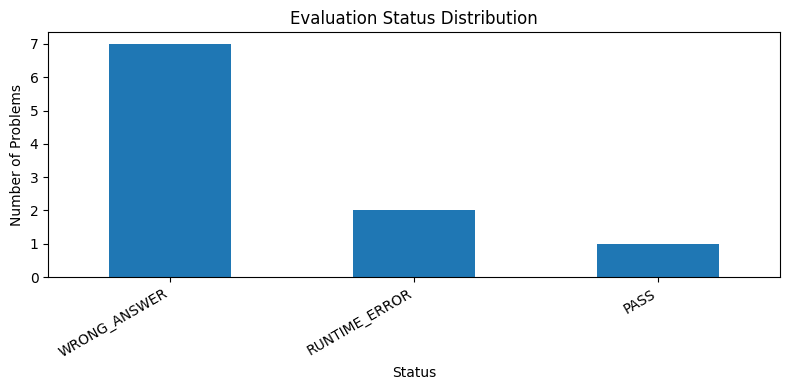

In [9]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(8, 4))
status_counts.plot(kind='bar')
plt.title('Evaluation Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Problems')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 6. 난이도별 성능


In [10]:
difficulty_order = ['easy', 'medium', 'hard']

difficulty_summary = (
    df.groupby('difficulty')
      .agg(
          problems=('problem_id', 'count'),
          passed=('passed', 'sum'),
          pass_rate=('passed', 'mean'),
          mean_test_pass_ratio=('test_pass_ratio', 'mean'),
          mean_completion_tokens=('completion_tokens', 'mean'),
          mean_generation_time=('generation_time', 'mean'),
      )
      .reindex(difficulty_order)
      .dropna(how='all')
)
display(difficulty_summary)


,problems,passed,pass_rate,mean_test_pass_ratio,mean_completion_tokens,mean_generation_time
difficulty,,,,,,
easy,5,1,0.2,0.677949,237.400000,2.201142
medium,2,0,0.0,0.000000,241.000000,2.208605
hard,3,0,0.0,0.564103,244.666667,2.242656


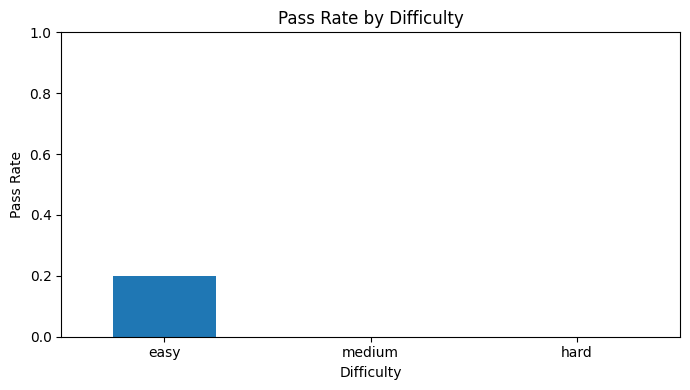

In [11]:
plt.figure(figsize=(7, 4))
difficulty_summary['pass_rate'].plot(kind='bar')
plt.title('Pass Rate by Difficulty')
plt.xlabel('Difficulty')
plt.ylabel('Pass Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. 문제별 성능 및 비용


In [20]:
problem_view = df[[
    'problem_id', 'title', 'difficulty', 'status',
    'passed_tests', 'total_tests', 'test_pass_ratio',
    'completion_tokens', 'generation_time',
    'tokens_per_second', 'execution_time'
]].sort_values(
    ['passed_tests', 'test_pass_ratio', 'difficulty'],
    ascending=[True, True, True],
)

display(problem_view)


,problem_id,title,difficulty,status,passed_tests,total_tests,test_pass_ratio,completion_tokens,generation_time,tokens_per_second,execution_time
2,1873_D,D. 1D Eraser,easy,WRONG_ANSWER,0,13,0.000000,626,5.689609,110.025129,6.448865
3,1883_B,B. Chemistry,medium,RUNTIME_ERROR,0,4,0.000000,223,2.044510,109.072597,0.024505
4,1883_C,C. Raspberries,medium,RUNTIME_ERROR,0,13,0.000000,259,2.372700,109.158330,0.076195
6,1899_B,B. 250 Thousand Tons of TNT,hard,WRONG_ANSWER,2,13,0.153846,344,3.148414,109.261378,0.215992
0,1873_A,A. Short Sort,easy,WRONG_ANSWER,3,5,0.600000,138,1.459637,94.544054,0.025685
7,1899_C,C. Yarik and Array,hard,WRONG_ANSWER,8,13,0.615385,211,1.933557,109.125310,0.137324
1,1873_B,B. Good Kid,easy,WRONG_ANSWER,12,13,0.923077,255,2.316546,110.077685,0.279661
8,1899_D,D. Yarik and Musical Notes,hard,WRONG_ANSWER,12,13,0.923077,179,1.645998,108.748581,0.168301
9,abc301_a,Overall Winner,easy,WRONG_ANSWER,13,15,0.866667,92,0.843709,109.042357,0.074722
5,1899_A,A. Game with Integers,easy,PASS,13,13,1.000000,76,0.696208,109.162718,0.064439


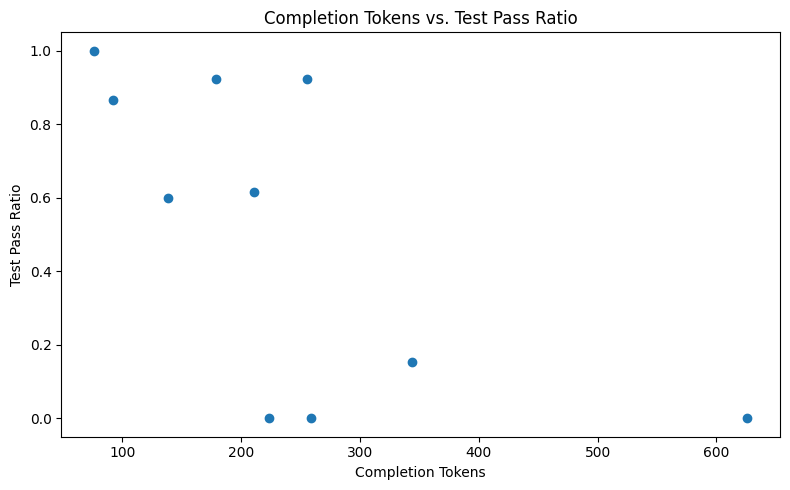

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['completion_tokens'], df['test_pass_ratio'])
plt.title('Completion Tokens vs. Test Pass Ratio')
plt.xlabel('Completion Tokens')
plt.ylabel('Test Pass Ratio')
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


## 8. 실패 사례 상세 분석


In [14]:
failed_df = df.loc[~df['passed']].copy()

failure_columns = [
    'problem_id', 'title', 'difficulty', 'status',
    'passed_tests', 'total_tests', 'test_pass_ratio',
    'error_message'
]
display(failed_df[failure_columns])


,problem_id,title,difficulty,status,passed_tests,total_tests,test_pass_ratio,error_message
0,1873_A,A. Short Sort,easy,WRONG_ANSWER,3,5,0.600000,"Test 0: expected='YES\nYES\nYES\nNO\nNO\nYES\n', actual='YES\nNO\nNO\nNO\nNO\nNO\n'"
1,1873_B,B. Good Kid,easy,WRONG_ANSWER,12,13,0.923077,"Test 0: expected='16\n2\n432\n430467210\n', actual='16\n2\n432\n0\n'"
2,1873_D,D. 1D Eraser,easy,WRONG_ANSWER,0,13,0.000000,"Test 0: expected='2\n1\n2\n1\n4\n3\n4\n0\n', actual='1\n1\n1\n1\n1\n1\n1\n0\n'"
3,1883_B,B. Chemistry,medium,RUNTIME_ERROR,0,4,0.000000,"Test 0: Traceback (most recent call last):\n File ""/tmp/phase1_eval_i6_9_spc/solution.py"", line 21, in <module>\n ..."
4,1883_C,C. Raspberries,medium,RUNTIME_ERROR,0,13,0.000000,"Test 0: Traceback (most recent call last):\n File ""/tmp/phase1_eval_ceueuvjy/solution.py"", line 33, in <module>\n ..."
6,1899_B,B. 250 Thousand Tons of TNT,hard,WRONG_ANSWER,2,13,0.153846,"Test 0: expected='1\n9\n0\n189114\n112141\n', actual='1\n13\n0\n370110\n187903\n'"
7,1899_C,C. Yarik and Array,hard,WRONG_ANSWER,8,13,0.615385,"Test 0: expected='15\n17\n8\n4\n-1000\n101\n10\n', actual='15\n17\n7\n4\n-1000\n101\n10\n'"
8,1899_D,D. Yarik and Musical Notes,hard,WRONG_ANSWER,12,13,0.923077,"Test 0: expected='0\n2\n1\n3\n19\n', actual='0\n1\n1\n3\n15\n'"
9,abc301_a,Overall Winner,easy,WRONG_ANSWER,13,15,0.866667,"Test 1: expected='T\n', actual='A\n'"


In [15]:
def show_failure(problem_id: str) -> None:
    matched = df.loc[df['problem_id'] == problem_id]
    if matched.empty:
        raise KeyError(f'Unknown problem_id: {problem_id}')

    row = matched.iloc[0]
    print('=' * 100)
    print(f"{row['problem_id']} | {row['title']} | {row['difficulty']} | {row['status']}")
    print('=' * 100)
    print('\n[Error message]')
    print(row.get('error_message'))
    print('\n[Extracted code]')
    print(row.get('extracted_code', ''))

    test_results = row.get('test_results') or []
    first_failed = next(
        (result for result in test_results if not result.get('passed', False)),
        None,
    )

    if first_failed is not None:
        print('\n[First failed test]')
        print('test_index:', first_failed.get('test_index'))
        print('status:', first_failed.get('status'))
        print('input:')
        print(first_failed.get('input_text', ''))
        print('expected:')
        print(first_failed.get('expected_output', ''))
        print('actual:')
        print(first_failed.get('actual_output', ''))
        print('stderr:')
        print(first_failed.get('stderr', ''))

# 예시
if not failed_df.empty:
    show_failure(failed_df.iloc[0]['problem_id'])


1873_A | A. Short Sort | easy | WRONG_ANSWER

[Error message]
Test 0: expected='YES\nYES\nYES\nNO\nNO\nYES\n', actual='YES\nNO\nNO\nNO\nNO\nNO\n'

[Extracted code]
def can_sort(cards):
    # Check if the cards are already sorted
    if cards == 'abc':
        return 'YES'
    
    # Check if there is exactly one mismatch
    mismatches = 0
    for i in range(3):
        if cards[i] != 'abc'[i]:
            mismatches += 1
    
    # If there is exactly one mismatch, it means we can swap to sort
    if mismatches == 1:
        return 'YES'
    
    return 'NO'

# Read input
t = int(input())
for _ in range(t):
    cards = input()
    print(can_sort(cards))

[First failed test]
test_index: 0
status: WRONG_ANSWER
input:
6
abc
acb
bac
bca
cab
cba

expected:
YES
YES
YES
NO
NO
YES

actual:
YES
NO
NO
NO
NO
NO

stderr:



## 9. 중첩 테스트 결과 펼치기


In [16]:
test_rows = []

for _, row in df.iterrows():
    for test_result in row.get('test_results', []) or []:
        test_rows.append({
            'problem_id': row['problem_id'],
            'difficulty': row['difficulty'],
            **test_result,
        })

test_df = pd.DataFrame(test_rows)
print(f'Test bundles: {len(test_df)}')
display(test_df.head())


Test bundles: 115


,problem_id,difficulty,test_index,passed,status,input_text,expected_output,actual_output,execution_time,return_code,stderr
0,1873_A,easy,0,False,WRONG_ANSWER,6\nabc\nacb\nbac\nbca\ncab\ncba\n,YES\nYES\nYES\nNO\nNO\nYES\n,YES\nNO\nNO\nNO\nNO\nNO\n,0.005184,0,
1,1873_A,easy,1,True,PASS,1\nabc\n,YES\n,YES\n,0.005096,0,
2,1873_A,easy,2,True,PASS,3\nabc\nabc\nabc\n,YES\nYES\nYES\n,YES\nYES\nYES\n,0.005132,0,
3,1873_A,easy,3,False,WRONG_ANSWER,5\ncab\nacb\ncba\nbac\nbca\n,NO\nYES\nYES\nYES\nNO\n,NO\nNO\nNO\nNO\nNO\n,0.004843,0,
4,1873_A,easy,4,True,PASS,6\nabc\nabc\nabc\nabc\nabc\nabc\n,YES\nYES\nYES\nYES\nYES\nYES\n,YES\nYES\nYES\nYES\nYES\nYES\n,0.005136,0,


In [17]:
if not test_df.empty:
    test_status_summary = (
        test_df.groupby('status')
               .agg(count=('problem_id', 'count'))
               .sort_values('count', ascending=False)
    )
    test_status_summary['ratio'] = (
        test_status_summary['count'] / len(test_df)
    )
    display(test_status_summary)


,count,ratio
status,,
PASS,63,0.547826
WRONG_ANSWER,35,0.304348
RUNTIME_ERROR,17,0.147826


## 10. 요약 파일 저장


In [18]:
summary_path = RESULT_PATH.with_name('summary.csv')

summary_columns = [
    'problem_id', 'title', 'platform', 'difficulty',
    'strategy', 'model_name', 'passed', 'status',
    'passed_tests', 'total_tests', 'test_pass_ratio',
    'prompt_tokens', 'completion_tokens', 'total_tokens',
    'generation_time', 'tokens_per_second', 'execution_time',
    'error_message'
]

available_columns = [
    column for column in summary_columns if column in df.columns
]

df[available_columns].to_csv(
    summary_path,
    index=False,
    encoding='utf-8-sig',
)

print(f'Saved summary: {summary_path}')


Saved summary: ../direct_stdin/summary.csv


## 해석 시 주의사항

- `passed_tests / total_tests`는 개별 입력 수가 아니라 **LiveCodeBench test bundle 단위**이다.
- 현재 결과는 전체 LiveCodeBench v6가 아니라 **stdin subset** 결과이다.
- 문제 수가 적은 smoke test에서는 난이도별 Pass Rate를 일반화하면 안 된다.
- Direct, Self-Planning, Teacher-Planning 비교 시 동일한 problem ID 집합을 사용해야 한다.
